In [ ]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as transforms
import torchvision.models as models
from PIL import Image
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import time
import random

: 

In [2]:
# Set random seed for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"Random seed set to {seed}")

set_seed(42)

# Set device
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

DATA_ROOT = r"D:\Uni\Lab\inebriation-voice-detector\data\processed"
TRAIN_DIR = os.path.join(DATA_ROOT, "TRAIN")
VAL_DIR = os.path.join(DATA_ROOT, "VALIDATION")
TEST_DIR = os.path.join(DATA_ROOT, "TEST")

# Create output directory
os.makedirs("output", exist_ok=True)

# Define classes
classes = ['SOBER', 'DRUNK']
class_to_idx = {cls: idx for idx, cls in enumerate(classes)}
idx_to_class = {idx: cls for idx, cls in enumerate(classes)}

Random seed set to 42
Using device: cuda:0


In [3]:
#Dataset Class
class SpectrogramDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.classes = ['SOBER', 'DRUNK']
        self.class_to_idx = {cls: idx for idx, cls in enumerate(self.classes)}
        self.samples = self._make_dataset()
        
    def _make_dataset(self):
        samples = []
        for class_name in os.listdir(self.root_dir):
            class_path = os.path.join(self.root_dir, class_name)
            if os.path.isdir(class_path):
                class_idx = self.class_to_idx[class_name]
                for filename in os.listdir(class_path):
                    if filename.endswith(('.jpg', '.jpeg', '.png')):
                        samples.append((
                            os.path.join(class_path, filename),
                            class_idx
                        ))
        return samples
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert('RGB')
        
        if self.transform:
            image = self.transform(image)
            
        return image, label



In [4]:
# Data Preparation
# Define transforms
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Initialize datasets

train_dataset = SpectrogramDataset(TRAIN_DIR, transform)
val_dataset = SpectrogramDataset(VAL_DIR, transform)
test_dataset = SpectrogramDataset(TEST_DIR, transform)

# Create balanced sampler
class_counts = torch.tensor([len([x for x in train_dataset.samples if x[1] == i]) for i in range(2)])
class_weights = 1. / class_counts
sample_weights = torch.tensor([class_weights[y] for _, y in train_dataset.samples])
sampler = WeightedRandomSampler(sample_weights, len(sample_weights))

# Create data loaders
BATCH_SIZE = 100
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [5]:
#Model
def create_model():
    # Load pretrained ResNet18
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    
    # Freeze all layers except last block
    for name, param in model.named_parameters():
        if not name.startswith('layer4'):
            param.requires_grad = False
    
    # Replace final layer for binary classification
    model.fc = nn.Sequential(
        nn.Linear(model.fc.in_features, 1),
        nn.Sigmoid()
    )
    
    # Count parameters
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    
    print(f"\nModel created:")
    print(f"Total parameters: {total_params:,}")
    print(f"Trainable parameters: {trainable_params:,}")
    
    return model.to(device)

model = create_model()


Model created:
Total parameters: 11,177,025
Trainable parameters: 8,394,241


In [6]:
#Loss Function
class WeightedBCELoss(nn.Module):
    """Weighted Binary Cross Entropy as per ADLAIA paper"""
    def __init__(self, weight_pos=0.9, weight_neg=0.1):
        super().__init__()
        self.weight_pos = weight_pos
        self.weight_neg = weight_neg
        
    def forward(self, inputs, targets):
        loss = - (self.weight_pos * targets * torch.log(inputs + 1e-7) + 
                 self.weight_neg * (1 - targets) * torch.log(1 - inputs + 1e-7))
        return torch.mean(loss)

criterion = WeightedBCELoss(weight_pos=0.9, weight_neg=0.1)
print("\nUsing weighted BCE loss with:")
print(f"Positive weight (DRUNK): 0.9")
print(f"Negative weight (SOBER): 0.1")




Using weighted BCE loss with:
Positive weight (DRUNK): 0.9
Negative weight (SOBER): 0.1


In [7]:
# Training Setup
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

print("\nTraining setup:")
print(f"Optimizer: Adam(lr=0.001)")
print(f"LR scheduler: StepLR(step_size=10, gamma=0.1)")


Training setup:
Optimizer: Adam(lr=0.001)
LR scheduler: StepLR(step_size=10, gamma=0.1)


In [8]:


# Evaluation Function
def evaluate(model, data_loader):
    model.eval()
    all_preds = []
    all_labels = []
    running_loss = 0.0
    
    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs = inputs.to(device)
            labels = labels.to(device).float()
            
            outputs = model(inputs).squeeze()
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * inputs.size(0)
            preds = (outputs >= 0.5).float()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    # Calculate metrics
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    
    # Calculate UAR (Unweighted Average Recall)
    cm = confusion_matrix(all_labels, all_preds)
    if cm.shape == (2, 2):  # binary classification
        tn, fp, fn, tp = cm.ravel()
        tnr = tn / (tn + fp) if (tn + fp) > 0 else 0
        tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
        uar = (tpr + tnr) / 2
    else:  # handle case when one class is missing in predictions
        uar = accuracy_score(all_labels, all_preds)  # fallback
    
    metrics = {
        'loss': running_loss / len(data_loader.dataset),
        'accuracy': accuracy_score(all_labels, all_preds),
        'uar': uar,
        'confusion_matrix': cm
    }
    
    return metrics


Epoch 1/30
----------


Training: 100%|████████████████████████████████████████████████████████████████████████| 75/75 [01:08<00:00,  1.09it/s]


Train Loss: 0.1584 | Val Loss: 0.1870
Train Acc: 0.5246 | Val Acc: 0.3662
Train UAR: 0.5334 | Val UAR: 0.5371
Validation Confusion Matrix:
[[ 442 3299]
 [  69 1504]]
Saved new best model (based on UAR)!

Epoch 2/30
----------


Training: 100%|████████████████████████████████████████████████████████████████████████| 75/75 [01:08<00:00,  1.10it/s]


Train Loss: 0.1040 | Val Loss: 0.2488
Train Acc: 0.6787 | Val Acc: 0.4057
Train UAR: 0.6870 | Val UAR: 0.5510
Validation Confusion Matrix:
[[ 729 3012]
 [ 146 1427]]
Saved new best model (based on UAR)!

Epoch 3/30
----------


...

Training: 100%|████████████████████████████████████████████████████████████████████████| 75/75 [01:10<00:00,  1.07it/s]


Train Loss: 0.0021 | Val Loss: 0.7064
Train Acc: 0.9948 | Val Acc: 0.6505
Train UAR: 0.9948 | Val UAR: 0.6129
Validation Confusion Matrix:
[[2638 1103]
 [ 754  819]]
No improvement in UAR for 4/5 epochs

Epoch 13/30
----------


Training: 100%|████████████████████████████████████████████████████████████████████████| 75/75 [01:07<00:00,  1.11it/s]


Train Loss: 0.0015 | Val Loss: 0.6945
Train Acc: 0.9977 | Val Acc: 0.6511
Train UAR: 0.9977 | Val UAR: 0.6128
Validation Confusion Matrix:
[[2644 1097]
 [ 757  816]]
No improvement in UAR for 5/5 epochs

Early stopping triggered after 5 epochs without improvement!

Training completed. Loaded best model weights.


C:\Users\krevi\AppData\Local\Temp\ipykernel_19800\1418966645.py:85: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("output/best_model.pth"))


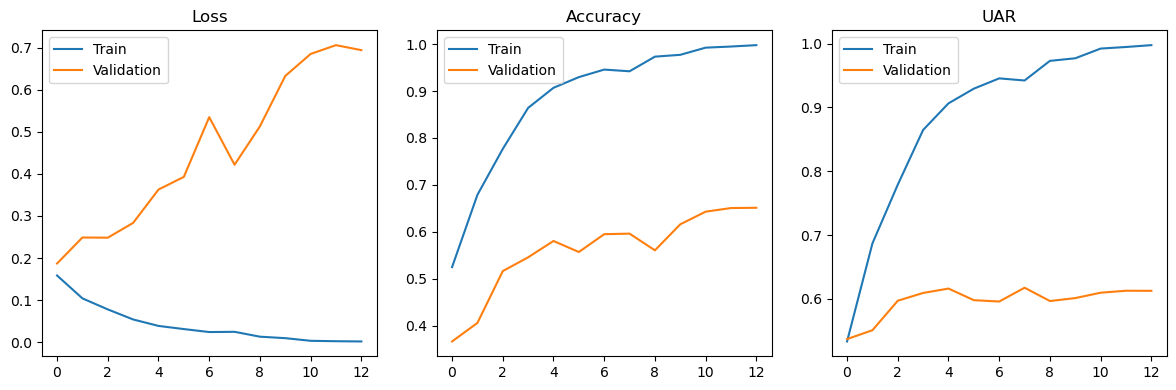

C:\Users\krevi\AppData\Local\Temp\ipykernel_19800\1418966645.py:126: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("output/best_model.pth"))


Final Test Results:
Accuracy: 0.5832
UAR: 0.5920
Confusion Matrix:
[[1058 1129]
 [ 557 1301]]


In [9]:
# Training Loop with Early Stopping
def train_model(model, train_loader, val_loader, num_epochs=30, patience=5):
    best_uar = 0
    no_improvement = 0
    history = {
        'train_loss': [], 'val_loss': [],
        'train_acc': [], 'val_acc': [],
        'train_uar': [], 'val_uar': []
    }
    
    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        print("-" * 10)
        
        # Training phase
        model.train()
        train_loss = 0
        train_preds = []
        train_labels = []
        
        for inputs, labels in tqdm(train_loader, desc="Training"):
            inputs, labels = inputs.to(device), labels.to(device).float()
            
            optimizer.zero_grad()
            outputs = model(inputs).squeeze()
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item() * inputs.size(0)
            preds = (outputs >= 0.5).float()
            train_preds.extend(preds.cpu().numpy())
            train_labels.extend(labels.cpu().numpy())
        
        # Calculate training metrics
        train_loss = train_loss / len(train_loader.dataset)
        train_acc = accuracy_score(train_labels, train_preds)
        
        # Calculate training UAR
        train_cm = confusion_matrix(train_labels, train_preds)
        if train_cm.shape == (2, 2):
            tn, fp, fn, tp = train_cm.ravel()
            tnr = tn / (tn + fp) if (tn + fp) > 0 else 0
            tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
            train_uar = (tpr + tnr) / 2
        else:
            train_uar = train_acc
        
        # Validation phase
        val_metrics = evaluate(model, val_loader)
        
        # Update LR scheduler
        scheduler.step()
        
        # Save history
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_metrics['loss'])
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_metrics['accuracy'])
        history['train_uar'].append(train_uar)
        history['val_uar'].append(val_metrics['uar'])
        
        # Print metrics
        print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_metrics['loss']:.4f}")
        print(f"Train Acc: {train_acc:.4f} | Val Acc: {val_metrics['accuracy']:.4f}")
        print(f"Train UAR: {train_uar:.4f} | Val UAR: {val_metrics['uar']:.4f}")
        print("Validation Confusion Matrix:")
        print(val_metrics['confusion_matrix'])
        
        # Early stopping check
        if val_metrics['uar'] > best_uar:
            best_uar = val_metrics['uar']
            no_improvement = 0
            torch.save(model.state_dict(), "output/best_model.pth")
            print("Saved new best model (based on UAR)!")
        else:
            no_improvement += 1
            print(f"No improvement in UAR for {no_improvement}/{patience} epochs")
            
            if no_improvement >= patience:
                print(f"\nEarly stopping triggered after {patience} epochs without improvement!")
                break
    
    # Load the best model weights before returning
    model.load_state_dict(torch.load("output/best_model.pth"))
    print("\nTraining completed. Loaded best model weights.")
    
    return history

# Train the model with early stopping
history = train_model(
    model, 
    train_loader, 
    val_loader, 
    num_epochs=30,
    patience=5  # Stop if no improvement for 5 epochs
)


# Plot training curves
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.plot(history['train_loss'], label='Train')
plt.plot(history['val_loss'], label='Validation')
plt.title('Loss')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(history['train_acc'], label='Train')
plt.plot(history['val_acc'], label='Validation')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(history['train_uar'], label='Train')
plt.plot(history['val_uar'], label='Validation')
plt.title('UAR')
plt.legend()

plt.tight_layout()
plt.savefig("output/training_curves.png")
plt.show()
# ======== END VISUALIZATION ========

# Load best model and evaluate on test set
model.load_state_dict(torch.load("output/best_model.pth"))
test_metrics = evaluate(model, test_loader)

print("\nFinal Test Results:")
print(f"Accuracy: {test_metrics['accuracy']:.4f}")
print(f"UAR: {test_metrics['uar']:.4f}")
print("Confusion Matrix:")
print(test_metrics['confusion_matrix'])

C:\Users\krevi\AppData\Local\Temp\ipykernel_19800\3338406334.py:28: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("output/best_model.pth"))



Final Test Results:
Loss: 0.5145
Accuracy: 0.5832
UAR: 0.5920
Confusion Matrix:
[[1058 1129]
 [ 557 1301]]


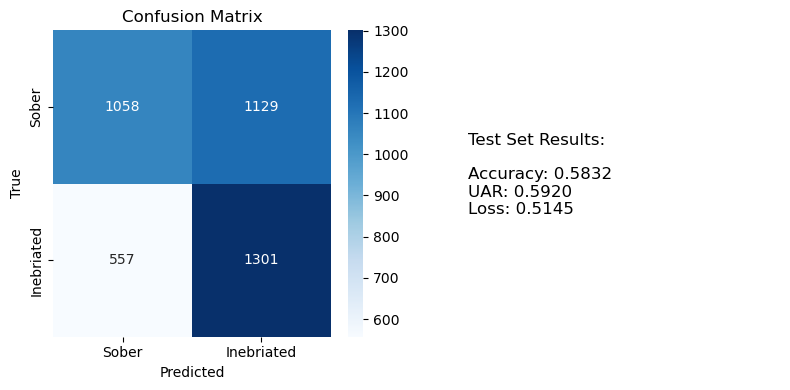

In [10]:
def plot_results(metrics, class_names):
    plt.figure(figsize=(8, 4))
    
    # Confusion matrix
    plt.subplot(1, 2, 1)
    sns.heatmap(metrics['confusion_matrix'], annot=True, fmt='d', 
                cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    
    # Metrics summary
    plt.subplot(1, 2, 2)
    plt.axis('off')
    metrics_text = (
        f"Test Set Results:\n\n"
        f"Accuracy: {metrics['accuracy']:.4f}\n"
        f"UAR: {metrics['uar']:.4f}\n"
        f"Loss: {metrics['loss']:.4f}\n"
    )
    plt.text(0.1, 0.5, metrics_text, fontsize=12, va='center')
    
    plt.tight_layout()
    plt.savefig("output/test_results.png")
    plt.show()

# Load best model and evaluate
model.load_state_dict(torch.load("output/best_model.pth"))
test_metrics = evaluate(model, test_loader)

print("\nFinal Test Results:")
print(f"Loss: {test_metrics['loss']:.4f}")
print(f"Accuracy: {test_metrics['accuracy']:.4f}")
print(f"UAR: {test_metrics['uar']:.4f}")
print("Confusion Matrix:")
print(test_metrics['confusion_matrix'])

# Plot results
plot_results(test_metrics, ['Sober', 'Inebriated'])  # Replace with your actual class names
